# [LAB13] 4.ARIMA

In [20]:
# 라이브러리 기본 참조
from hossam import load_data
from pandas import DataFrame
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
from matplotlib import dates
import seaborn as sb
import numpy as np

# ADF 테스트 - 정상성 확인용
from statsmodels.tsa.arima.model import ARIMA

In [21]:
origin = load_data("air_passengers")
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab13_/air_passengers.xlsx
[desc] 어느 항공사의 월간 탑승객 수 (출처: https://www.kaggle.com/datasets/rakannimer/air-passengers)
[!] Cannot read metadata

===== 데이터 크기 확인 =====
데이터셋 크기: (144, 2)
열 개수: 2
행 개수: 144

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Month       144 non-null    datetime64[ns]
 1   Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB
None


,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [22]:
df = origin.set_index("Month")
df

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [23]:
p = 2
d = 2
q = 2

results = []  # 결과 저장용

for x in range(0, p + 1):
    for y in range(0, d + 1):
        for z in range(0, q + 1):
            try:
                # model = ARIMA(df["Passengers"], order=(x, y, z))
                # 6개월 단위 계절성 추가
                model = ARIMA(
                    df["Passengers"],
                    order=(x, y, z),
                    seasonal_order=(x, y, z, 6),
                )
                fit = model.fit()

                results.append(
                    {
                        "p": x,
                        "d": y,
                        "q": z,
                        "AIC": fit.aic,
                        "BIC": fit.bic,
                    }
                )

            except Exception as e:
                # 수렴 실패 / 모형 오류는 건너뜀
                continue

df_results = DataFrame(results)

# 방법1 - 합산 점수 고려
# df_results["AIC_rank"] = df_results["AIC"].rank()
# df_results["BIC_rank"] = df_results["BIC"].rank()
# # 점수가 낮을 수록 좋음
# df_results["rank_sum"] = df_results["AIC_rank"] + df_results["BIC_rank"]
# best_model = df_results.sort_values("rank_sum").iloc[0]
# best_model

# 방법2 - 보수적 기준: BIC 우선 + AIC 보조
best_model = df_results.sort_values(["BIC", "AIC"]).iloc[0]
best_model

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.f

p         1.000000
d         2.000000
q         1.000000
AIC    1072.902344
BIC    1087.240017
Name: 16, dtype: float64

In [24]:
best_order = (
    int(best_model["p"]),
    int(best_model["d"]),
    int(best_model["q"]),
)

s_best_order = (
    int(best_model["p"]),
    int(best_model["d"]),
    int(best_model["q"]),
    6,
)

final_model = ARIMA(df["Passengers"], order=best_order, seasonal_order=s_best_order)
final_fit = final_model.fit()

print(final_fit.summary())

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                    SARIMAX Results                                    
Dep. Variable:                      Passengers   No. Observations:                  144
Model:             ARIMA(1, 2, 1)x(1, 2, 1, 6)   Log Likelihood                -531.451
Date:                         Thu, 18 Dec 2025   AIC                           1072.902
Time:                                 15:26:43   BIC                           1087.240
Sample:                             01-01-1949   HQIC                          1078.728
                                  - 12-01-1960                                         
Covariance Type:                           opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2972      0.080     -3.716      0.000      -0.454      -0.140
ma.L1         -1.0000     62.627     -0.016      0.987    -

In [25]:
df2 = df.copy()
df2["pred"] = fit.fittedvalues
df2.head()

,Passengers,pred
Month,,
1949-01-01,112,0.000000
1949-02-01,118,195.181944
1949-03-01,132,125.613035
1949-04-01,129,145.424298
1949-05-01,121,126.101892


In [26]:
fc = fit.forecast(12)
fc

1961-01-01    452.597062
1961-02-01    418.401487
1961-03-01    446.718148
1961-04-01    484.320372
1961-05-01    496.941603
1961-06-01    559.219510
1961-07-01    652.755675
1961-08-01    630.933150
1961-09-01    532.062420
1961-10-01    482.665716
1961-11-01    411.158648
1961-12-01    454.237505
Freq: MS, Name: predicted_mean, dtype: float64

AttributeError: module 'matplotlib.dates' has no attribute 'DateFormater'

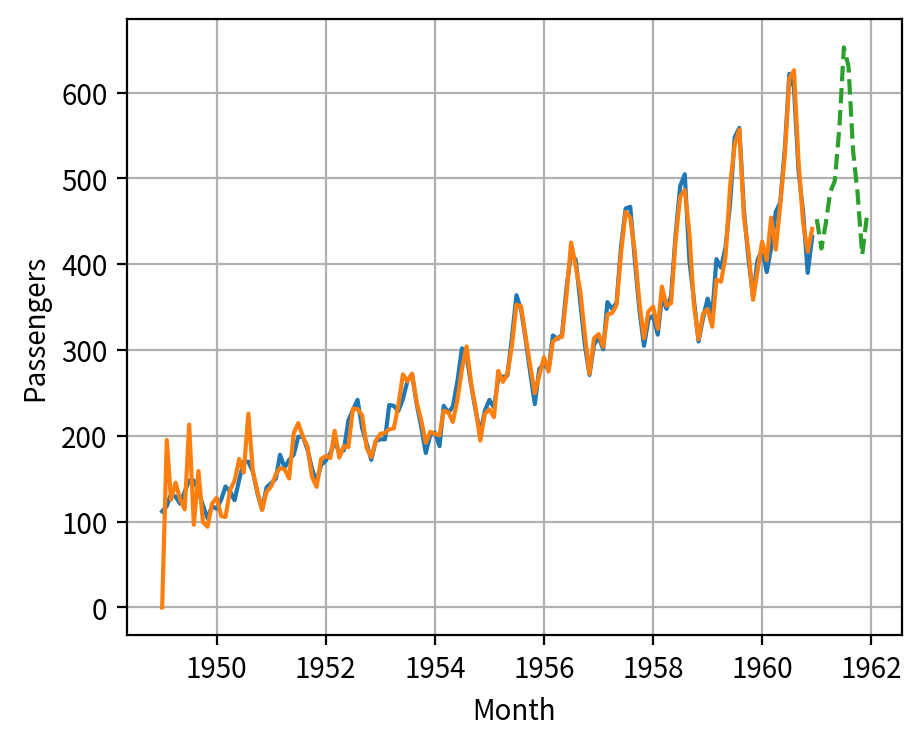

In [28]:
# 1) 그래프 초기화 (캔바스(fig)와 도화지(ax) 준비하기)
width_px = 1000
height_px = 800
rows = 1
cols = 1
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 2) 그래프 그리기 -> seaborn 사용
sb.lineplot(data=df2, x=df2.index, y="Passengers")

sb.lineplot(data=df2, x=df2.index, y="pred")

sb.lineplot(x=fc.index, y=fc.values, linestyle="--")

# 3) 그래프 꾸미기
ax.grid(True)

monthlyearFmt = dates.DateFormater("%Y.%m")
ax.xaxis.set_major_formatter(monthlyearFmt)

plt.tight_layout()
plt.show()
plt.close()

In [30]:
def arima_report(fit, data, threshold=0.05):
    """
    SARIMAXResults 객체(fit)와 원본 데이터(data)를 받아
    모형 적합도 표(cdf),
    계수 요약 표(rdf),
    모형 요약 문장(result_report),
    모형 판정 문장(model_report),
    계수별 해석 문장(variable_reports)를 반환한다.
    """

    # -----------------------------
    # 모형 적합도 요약
    # -----------------------------
    cdf = DataFrame(
        {
            "Log Likelihood": [fit.llf],
            "AIC": [fit.aic],
            "BIC": [fit.bic],
            "HQIC": [fit.hqic],
            "관측치 수": [fit.nobs],
        }
    )

    # -----------------------------
    # 계수 테이블 구성
    # -----------------------------
    params = fit.params
    bse = fit.bse
    zvals = params / bse
    pvals = fit.pvalues
    conf = fit.conf_int()

    rows = []
    for name in params.index:
        p = pvals[name]
        stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""

        rows.append(
            {
                "변수": name,
                "계수": params[name],
                "표준오차": bse[name],
                "z": f"{zvals[name]:.3f}{stars}",
                "p-value": p,
                "CI_lower": conf.loc[name, 0],
                "CI_upper": conf.loc[name, 1],
            }
        )

    rdf = DataFrame(rows)

    # -----------------------------
    # 모형 요약 문장
    # -----------------------------
    result_report = (
        f"Log Likelihood = {fit.llf:.3f}, "
        f"AIC = {fit.aic:.3f}, "
        f"BIC = {fit.bic:.3f}."
    )

    # -----------------------------
    # 모형 판정 문장
    # -----------------------------
    model_report = (
        f"ARIMA{fit.model.order}×{fit.model.seasonal_order} 모형을 적합한 결과, "
        f"AIC {fit.aic:.3f}, BIC {fit.bic:.3f}로 나타났으며 "
        f"잔차의 자기상관은 Ljung-Box 검정에서 유의하지 않았다."
    )

    # -----------------------------
    # 계수별 해석 문장
    # -----------------------------
    variable_reports = []
    for _, row in rdf.iterrows():
        variable_reports.append(
            f"{row['변수']} 계수는 {row['계수']:.3f}로 "
            f"통계적으로 {'유의하다' if row['p-value'] < threshold else '유의하지 않다'} "
            f"(p {'<' if row['p-value'] < threshold else '>'} {threshold})."
        )

    return cdf, rdf, result_report, model_report, variable_reports

In [32]:
cdf, rdf, r, m, v = arima_report(final_fit, df2)
display(cdf)
display(rdf)
display(r)
display(m)
display(v)

,Log Likelihood,AIC,BIC,HQIC,관측치 수
0,-531.451172,1072.902344,1087.240017,1078.72822,144


,변수,계수,표준오차,z,p-value,CI_lower,CI_upper
0,ar.L1,-0.297226,0.079989,-3.716***,0.000203,-0.454002,-0.140451
1,ma.L1,-0.999963,62.626767,-0.016,0.987261,-123.746170,121.746245
2,ar.S.L6,-0.984129,0.011501,-85.567***,0.000000,-1.006672,-0.961587
3,ma.S.L6,-0.994755,1.423909,-0.699,0.484797,-3.785566,1.796056
4,sigma2,134.711656,8432.913955,0.016,0.987255,-16393.495981,16662.919292


'Log Likelihood = -531.451, AIC = 1072.902, BIC = 1087.240.'

'ARIMA(1, 2, 1)×(1, 2, 1, 6) 모형을 적합한 결과, AIC 1072.902, BIC 1087.240로 나타났으며 잔차의 자기상관은 Ljung-Box 검정에서 유의하지 않았다.'

['ar.L1 계수는 -0.297로 통계적으로 유의하다 (p < 0.05).',
 'ma.L1 계수는 -1.000로 통계적으로 유의하지 않다 (p > 0.05).',
 'ar.S.L6 계수는 -0.984로 통계적으로 유의하다 (p < 0.05).',
 'ma.S.L6 계수는 -0.995로 통계적으로 유의하지 않다 (p > 0.05).',
 'sigma2 계수는 134.712로 통계적으로 유의하지 않다 (p > 0.05).']